<a href="https://colab.research.google.com/github/hakeemwright93/Quantamental-Credit-Arbitrage-Engine/blob/main/Credit_Spread_Mean_Reversion_Scanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This installs the tools we need to get financial data
!pip install pandas_datareader yfinance matplotlib

In [ ]:
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt

# 1. Define the timeframe (Last 5 years)
start = datetime.datetime(2021, 1, 1)
end = datetime.datetime.now()

# 2. Pull the data from FRED
# 'BAA10Y' is the pre-calculated spread between Baa bonds and the 10Y Treasury
data = web.DataReader('BAA10Y', 'fred', start, end)

# 3. Rename it for clarity
data.columns = ['Credit_Spread']

print("Data successfully loaded!")
data.tail() # Shows the most recent 5 days

Data successfully loaded!


,Credit_Spread
DATE,
2026-04-03,NaN
2026-04-06,1.70
2026-04-07,1.75
2026-04-08,1.73
2026-04-09,1.73


In [ ]:
# Calculate the Rolling Average and Volatility
window = 252 # One trading year
data['Mean'] = data['Credit_Spread'].rolling(window=window).mean()
data['Std_Dev'] = data['Credit_Spread'].rolling(window=window).std()

# Calculate the Z-Score: (Current - Average) / Volatility
data['Z_Score'] = (data['Credit_Spread'] - data['Mean']) / data['Std_Dev']

print("Signals calculated. Ready to visualize.")

Signals calculated. Ready to visualize.


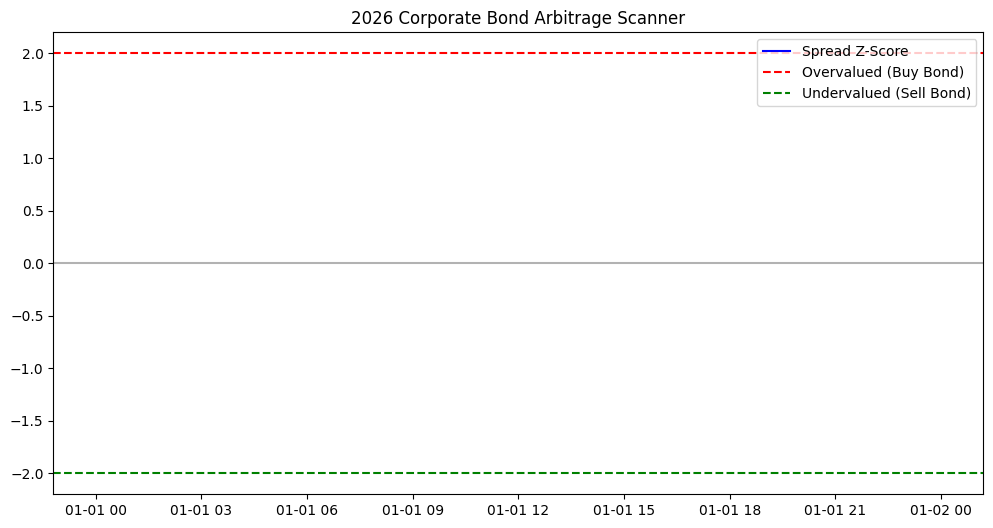

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Z_Score'], label='Spread Z-Score', color='blue')

# Draw the "Threshold" lines
plt.axhline(2, color='red', linestyle='--', label='Overvalued (Buy Bond)')
plt.axhline(-2, color='green', linestyle='--', label='Undervalued (Sell Bond)')
plt.axhline(0, color='black', alpha=0.3)

plt.title('2026 Corporate Bond Arbitrage Scanner')
plt.legend()
plt.show()

In [10]:
from google import genai
from google.colab import userdata, files
from IPython.display import display, Markdown

# 1. Pull the key using your specific name
GOOGLE_API_KEY = userdata.get('CreditScannerKey')
client = genai.Client(api_key=GOOGLE_API_KEY)

# 2. Upload the 'Description of Statistics - Ford.pdf'
print("Step 1: Upload the Ford Exhibit 4-C PDF.")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 3. Analyze the Bond
print(f"Step 2: Analyzing {file_name}...")

prompt = """
Analyze this bond indenture as a Senior Credit Analyst.
Extract these 4 key points into a professional table:
1. Change of Control (101% repurchase clause?)
2. Negative Pledge (Secured debt restrictions?)
3. Financial Covenants (Debt-to-EBITDA limits?)
4. Cross-Default triggers.

Finally, give it a 'Covenant Strength Score' from 1-10.
"""

bond_file = client.files.upload(file=file_name)

# 4. Generate and RENDER the final report
response = client.models.generate_content(
    model="gemini-flash-latest",
    contents=[bond_file, prompt]
)

print("\n--- ANALYSIS COMPLETE ---")
# This renders the table visually for your portfolio screenshot
display(Markdown(response.text))

Step 1: Upload the Ford Exhibit 4-C PDF.


Saving Description of Statistics - Ford.pdf to Description of Statistics - Ford (5).pdf
Step 2: Analyzing Description of Statistics - Ford (5).pdf...

--- ANALYSIS COMPLETE ---


To: Investment Committee / Credit Risk Department
From: Senior Credit Analyst
Subject: Covenant Analysis – Ford Motor Credit Company LLC (Indenture dated March 16, 2015)

This analysis covers the "Description of Debt Securities" for the 2026 Notes and various EMTN Notes issued by Ford Motor Credit Company LLC. This indenture represents a typical "covenant-light" structure common among investment-grade captive finance issuers.

### **Covenant Summary Table**

| Key Point | Finding | Credit Implication |
| :--- | :--- | :--- |
| **1. Change of Control** | **Not Present.** The document contains no "Put" option or 101% repurchase requirement upon a change of control. | **High Risk.** Bondholders have no protection if Ford Motor Credit is acquired by a lower-rated entity or undergoes a leveraged buyout. |
| **2. Negative Pledge** | **Limited.** Page 5 (Limitation on Liens) prohibits securing other debt without "equally and ratably" securing these notes. However, it includes a **5% basket** of Consolidated Net Tangible Assets (CNTA) and various carved-out exceptions. | **Moderate Protection.** Prevents significant structural subordination of these unsecured notes, though the 5% CNTA basket provides management with meaningful flexibility to pledge assets. |
| **3. Financial Covenants** | **Not Present.** There are no maintenance covenants regarding Debt-to-EBITDA, Interest Coverage, or Minimum Net Worth. | **Neutral/Weak.** Typical for high-grade credits, but offers no "early warning" triggers if the issuer's balance sheet health deteriorates. |
| **4. Cross-Default** | **Not Present (in the provided summary).** The "Events of Default" section (Page 5) lists only defaults specific to the Indenture. It explicitly states a default on one series "will not necessarily constitute" a default for another. | **High Risk.** A default on other major bank debt or separate bond series does not automatically trigger an event of default here, limiting the Trustee's ability to accelerate payment. |

***

### **Covenant Strength Score: 3 / 10**

**Rationale:**
As a Senior Credit Analyst, I categorize this indenture as **exceptionally weak** from a lender-protection standpoint. 

*   **Pros:** The Negative Pledge (Limitation on Liens) provides the bare minimum protection to ensure unsecured bondholders aren't pushed behind new secured lenders in the capital stack. 
*   **Cons:** The absence of a **Change of Control Put** is a major deficiency, leaving investors exposed to "event risk." Furthermore, the lack of a **Cross-Default** clause is aggressive, as it forces bondholders to wait for a payment default on *their specific series* rather than acting when the issuer's broader financial condition collapses. 

**Investment Verdict:** These securities are "pure-play" credit bets on the survival of Ford Motor Credit. Investors are relying entirely on the issuer's liquidity and investment-grade status rather than any structural protections within the indenture.

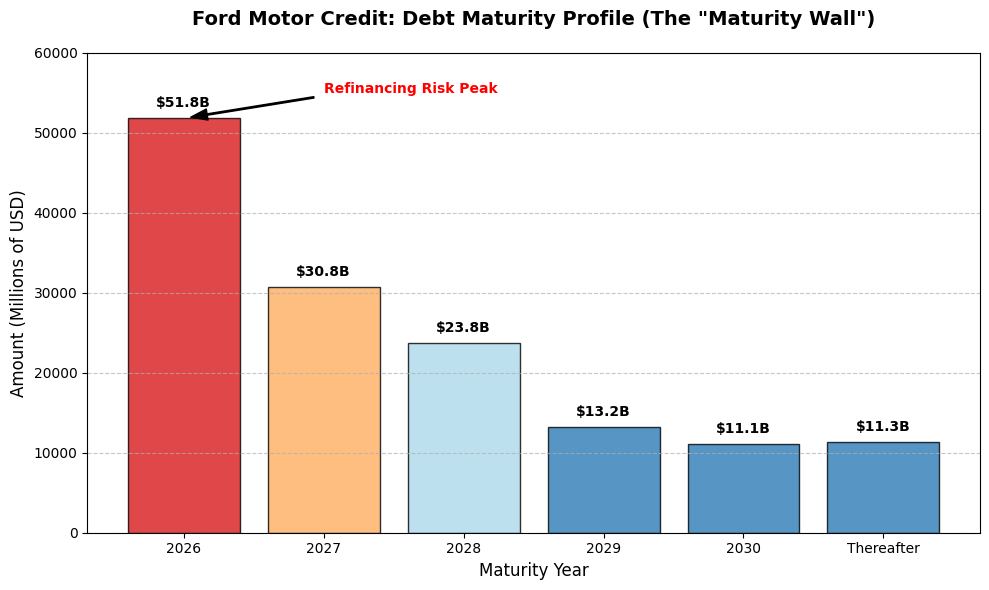

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from Ford Motor Credit Note 9 (Maturities as of Dec 31, 2025)
# Values in Millions of USD
data = {
    'Year': ['2026', '2027', '2028', '2029', '2030', 'Thereafter'],
    'Debt_Amount': [51806, 30760, 23761, 13194, 11073, 11310]
}

df = pd.DataFrame(data)

# Create the visualization
plt.figure(figsize=(10, 6))
colors = ['#d7191c', '#fdae61', '#abd9e9', '#2c7bb6', '#2c7bb6', '#2c7bb6'] # Red for high-pressure year
bars = plt.bar(df['Year'], df['Debt_Amount'], color=colors, edgecolor='black', alpha=0.8)

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, f'${yval/1000:.1f}B', ha='center', va='bottom', fontweight='bold')

# Professional formatting
plt.title('Ford Motor Credit: Debt Maturity Profile (The "Maturity Wall")', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Amount (Millions of USD)', fontsize=12)
plt.xlabel('Maturity Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 60000) # Give some space for labels

# Adding a 'Quant Note' as an annotation
plt.annotate('Refinancing Risk Peak', xy=(0, 51806), xytext=(1, 55000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()